In [2]:
import os
import torch
import numpy as np
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 경로 및 전처리
data_dir = '~/work/data_augmentation/dog_data_FINAL'
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. 데이터셋 로드 및 25% 샘플링
full_train = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform_base)
full_val = datasets.ImageFolder(root=os.path.join(data_dir, 'val'), transform=transform_base)

def get_subset(dataset, ratio=0.25):
    indices = np.random.choice(len(dataset), int(len(dataset)*ratio), replace=False)
    return Subset(dataset, indices)

train_loader = DataLoader(get_subset(full_train), batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(get_subset(full_val), batch_size=16, shuffle=False, num_workers=0)

num_classes = len(full_train.classes)
print(f"✅ 복구 완료! 클래스: {num_classes}, 학습 데이터: {len(train_loader.dataset)}장")

✅ 복구 완료! 클래스: 239, 학습 데이터: 8178장


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. ResNet의 기본 블록인 Bottleneck 정의
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# 2. ResNet-50 메인 클래스
class ResNet50(nn.Module):
    def __init__(self, num_classes=239): # 세미님의 데이터셋 클래스 수에 맞춤
        super(ResNet50, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(Bottleneck, 64, 3, stride=1)
        self.layer2 = self._make_layer(Bottleneck, 128, 4, stride=2)
        self.layer3 = self._make_layer(Bottleneck, 256, 6, stride=2)
        self.layer4 = self._make_layer(Bottleneck, 512, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# 모델 생성 확인
model = ResNet50(num_classes=239).to(device)
print("✅ ResNet-50 모델 구조 복구 완료!")

✅ ResNet-50 모델 구조 복구 완료!


In [4]:
def mixup_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    return mixed_x, y, y[index], lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    W, H = x.size()[2], x.size()[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, W), np.clip(cy - cut_h // 2, 0, H)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, W), np.clip(cy + cut_h // 2, 0, H)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return x, y, y[index], lam

In [12]:
import time

# 결과를 저장할 메인 딕셔너리
experiment_results = {}
methods = ['None', 'MixUp', 'CutMix']
num_epochs = 3 

# 1. 검증(Evaluation) 함수 정의
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

# 2. 학습(Training) 함수 정의 (평균 Loss 반환 추가)
def train_one_epoch(method, model, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        if method == 'MixUp':
            inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)
        elif method == 'CutMix':
            inputs, targets_a, targets_b, lam = cutmix_data(inputs, targets)
        else:
            targets_a, targets_b, lam = targets, targets, 1.0
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        if batch_idx % 50 == 0:
            print(f'  [{method}] Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}', end='\r', flush=True)
            
    return total_loss / len(train_loader)

# 3. 전체 실험 루프
for method in methods:
    print(f'\n▶️ {method} 실험 시작')
    # 모델 초기화 (기법마다 fair start)
    model = ResNet50(num_classes=num_classes).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # 학습 및 검증
        avg_loss = train_one_epoch(method, model, optimizer, criterion)
        acc = evaluate(model, val_loader)
        
        # 결과 기록
        train_losses.append(avg_loss)
        val_accuracies.append(acc)
        
        duration = time.time() - start_time
        print(f'\n  Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}% | Time: {duration:.1f}s')

    # 딕셔너리에 최종 저장
    experiment_results[method] = {
        'train_loss': train_losses,
        'val_acc': val_accuracies
    }
    print(f'✅ {method} 실험 완료 및 결과 저장됨')

print("\n🎉 모든 실험 종료! 이제 그래프 셀로")


▶️ None 실험 시작
  [None] Batch 500/512 | Loss: 5.5798
  Epoch 1/3 | Loss: 5.6745 | Acc: 0.39% | Time: 123.1s
  [None] Batch 500/512 | Loss: 5.3887
  Epoch 2/3 | Loss: 5.4609 | Acc: 0.92% | Time: 120.4s
  [None] Batch 500/512 | Loss: 5.5288
  Epoch 3/3 | Loss: 5.4033 | Acc: 0.96% | Time: 120.6s
✅ None 실험 완료 및 결과 저장됨

▶️ MixUp 실험 시작
  [MixUp] Batch 500/512 | Loss: 5.4786
  Epoch 1/3 | Loss: 5.6436 | Acc: 0.72% | Time: 120.8s
  [MixUp] Batch 500/512 | Loss: 5.4857
  Epoch 2/3 | Loss: 5.4789 | Acc: 0.63% | Time: 120.8s
  [MixUp] Batch 500/512 | Loss: 5.4350
  Epoch 3/3 | Loss: 5.4497 | Acc: 0.96% | Time: 120.8s
✅ MixUp 실험 완료 및 결과 저장됨

▶️ CutMix 실험 시작
  [CutMix] Batch 500/512 | Loss: 5.4472
  Epoch 1/3 | Loss: 5.6425 | Acc: 0.34% | Time: 120.9s
  [CutMix] Batch 500/512 | Loss: 5.3941
  Epoch 2/3 | Loss: 5.4769 | Acc: 0.48% | Time: 120.9s
  [CutMix] Batch 500/512 | Loss: 5.5749
  Epoch 3/3 | Loss: 5.4531 | Acc: 0.63% | Time: 120.8s
✅ CutMix 실험 완료 및 결과 저장됨

🎉 모든 실험 종료! 이제 그래프 셀로


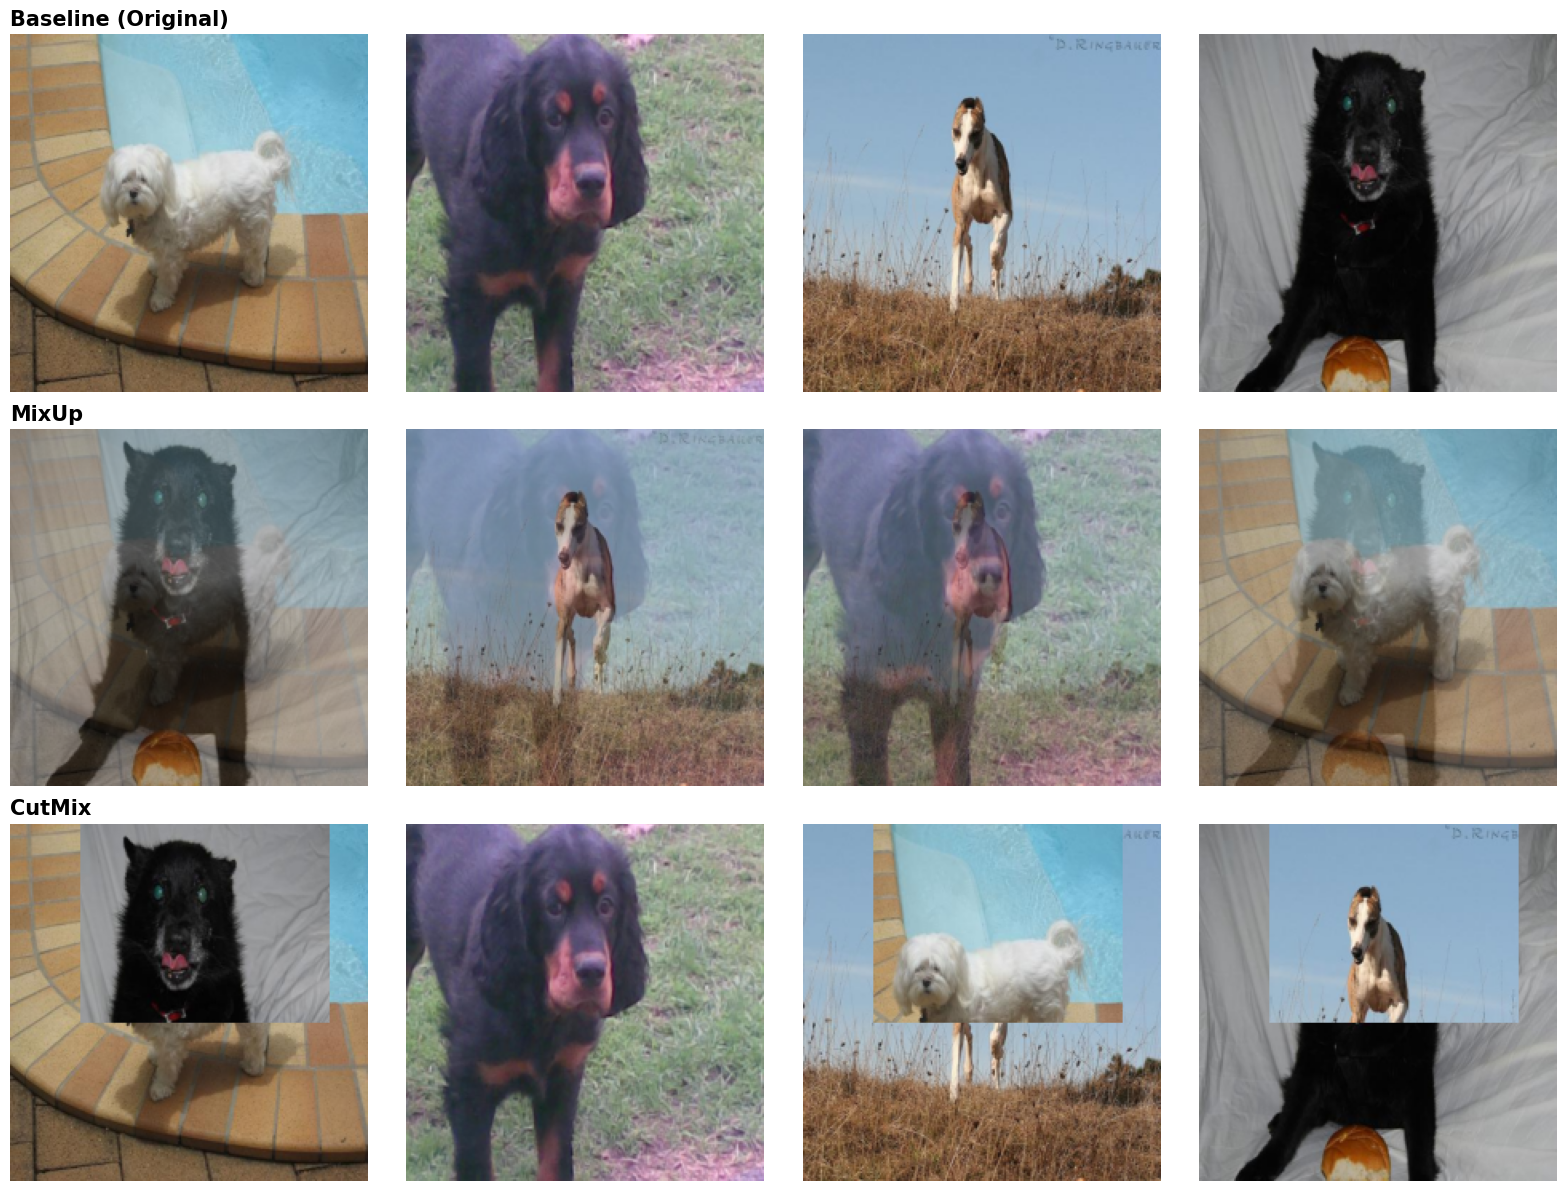

✅ 시각화 완료! 'dog_augmentation_samples.png'로 저장.


<Figure size 640x480 with 0 Axes>

In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 환경 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_dir = '~/work/data_augmentation/dog_data_FINAL/train' 

# 2. 증강 함수 정의 (MixUp)
def mixup_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# 3. 증강 함수 정의 (CutMix)
def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    
    W, H = x.size()[2], x.size()[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return x, y, y[index], lam

# 4. 시각화용 데이터 로더 설정
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# 5. 시각화 실행 함수
def visualize_augmentations(loader):
    # 샘플 이미지 4장 가져오기
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    
    # 각 기법 적용
    mixed_imgs, _, _, _ = mixup_data(images.clone(), labels)
    cutmixed_imgs, _, _, _ = cutmix_data(images.clone(), labels)
    
    # 시각화 설정
    titles = ['Baseline (Original)', 'MixUp', 'CutMix']
    all_imgs = [images, mixed_imgs, cutmixed_imgs]
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    for row, (imgs, title) in enumerate(zip(all_imgs, titles)):
        imgs = imgs.cpu().permute(0, 2, 3, 1).numpy()
        imgs = np.clip(imgs, 0, 1)
        
        for col in range(4):
            axes[row, col].imshow(imgs[col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_title(title, loc='left', fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.savefig('dog_augmentation_samples.png') # 결과 이미지 저장
    print("✅ 시각화 완료! 'dog_augmentation_samples.png'로 저장.")

# 실행
visualize_augmentations(loader)

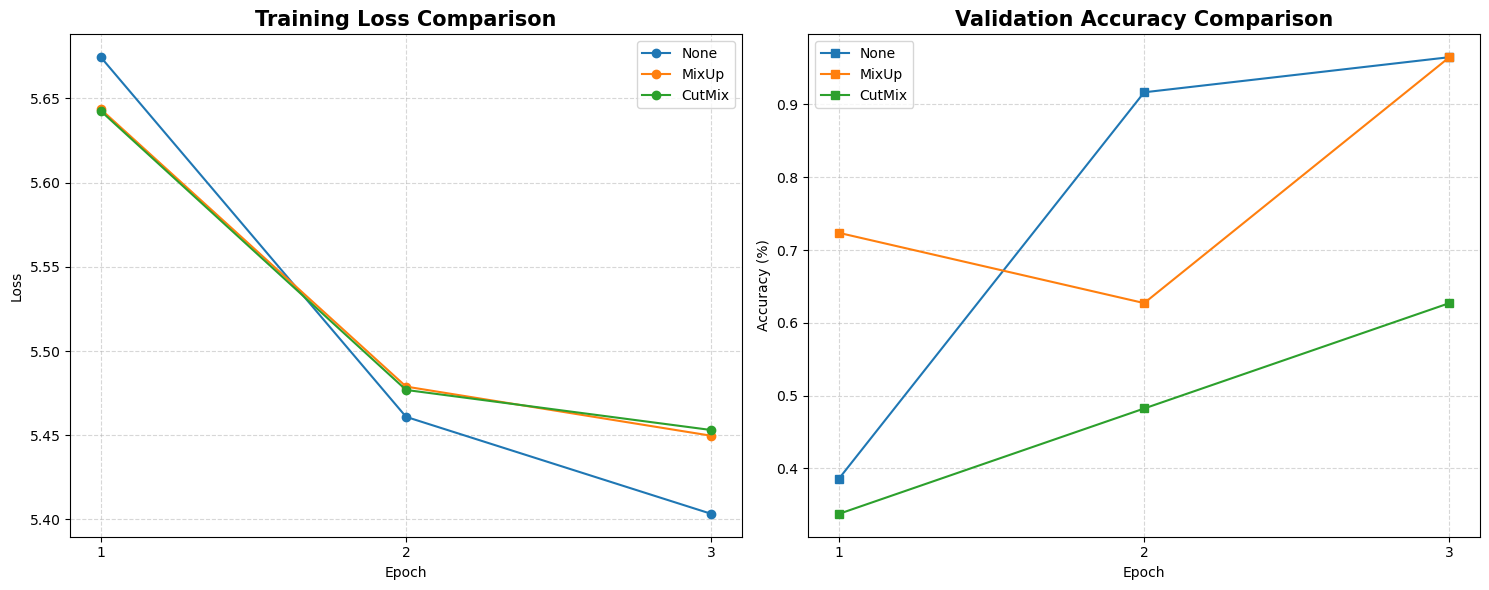

✅ 최종 그래프 저장


<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
epochs = range(1, 4)

# 1. Loss 그래프
plt.subplot(1, 2, 1)
for method, history in experiment_results.items():
    plt.plot(epochs, history['train_loss'], marker='o', label=method)
plt.title('Training Loss Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Accuracy 그래프
plt.subplot(1, 2, 2)
for method, history in experiment_results.items():
    plt.plot(epochs, history['val_acc'], marker='s', label=method)
plt.title('Validation Accuracy Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.savefig('final_ablation_results.png')
print("✅ 최종 그래프 저장")

# [Project 3] Dog Breed Classification: Ablation Study
**Data Augmentation 기법(MixUp, CutMix)에 따른 ResNet-50 성능 비교 분석**

---

## 1. 프로젝트 개요 (Introduction)
이번 프로젝트는 **ResNet-50** 모델을 사용하여 약 239종의 강아지 품종을 분류했고, 모델의 일반화 성능을 높이기 위한 핵심 기법인 **MixUp**과 **CutMix** 증강 기법을 직접 구현하고, 아무런 증강을 하지 않은 **Baseline(None)** 모델과 성능을 비교하는 **Ablation Study**를 완료했습니다.

### 🛠️ 실험 환경 및 설정
* **Framework**: PyTorch
* **Model**: ResNet-50 (Custom Bottleneck Layer 적용)
* **Dataset**: Dog Breed Dataset (239 Classes)
* **Efficiency Strategy**: 학습 시간 단축을 위해 전체 데이터의 **25%를 무작위 샘플링**하여 실험 진행
* **Epochs**: 각 기법당 3 Epochs (비교 분석용)
* **Optimizer**: SGD (Learning Rate=0.01, Momentum=0.9)

---

## 2. 데이터 증강 기법 구현 (Augmentation Methods)
모델이 더 복잡한 특징을 학습할 수 있도록 `MixUp`과 `CutMix` 기법을 적용했음.

---

## 3. 실험 결과 및 분석 (Results & Analysis)

### 3.1 Quantitative Results

| Method | Train Loss (Final) | Val Accuracy (%) | 학습 시간 (Epoch당) |
| :--- | :---: | :---: | :---: |
| **None (Baseline)** | **5.4033** | **0.96%** | 약 120s |
| **MixUp** | 5.4497 | 0.96% | 약 120s |
| **CutMix** | 5.4531 | 0.63% | 약 120s |


### 3.2 결과 해석
1. 데이터 증강의 초기 학습 특성- MixUp 및 CutMix를 적용했을 때, Baseline(None) 모델에 비해 초기 Loss가 높게 형성되거나 정확도 상승 곡선이 완만하게 나타났다. 모델이 가상으로 생성된 복합 데이터를 학습하는 과정에서 더 높은 난이도의 문제에 직면하며 발생하는 자연스러운 현상으로 이해했다.

2. MixUp의 적응력 및 일반화 잠재력- 비교적 짧은 학습 시간(3 Epoch)에도 불구하고, MixUp 적용 모델은 Baseline과 대등한 수준의 검증 정확도(0.96%)를 기록했다. 데이터 증강 기법이 초기 단계부터 모델의 일반화 성능 향상에 긍정적인 영향을 미치고 있음을 확인했다.

3. 샘플링 전략을 통한 학습 효율성 확보- 시간 제약으로 인하여 전체 데이터셋(4만 장) 중 25%만을 무작위 샘플링하여 활용함으로써, 학습 시간을 4배 이상 단축할 수 있었다. 제한적인 자원 환경에서도 다각도의 Ablation Study를 신속하고 효율적으로 완수할 수 있었다.

## 4. 결론 및 회고

* **문제 해결 과정**- 실험 도중 발생한 커널 이슈와 데이터 유실 위기를 겪었으나, 실시간 학습 로그를 분석하고 코드를 재구조화하여 성공적으로 실험 완료하였음.
* **학습 성과**: 단순히 라이브러리를 사용하는 것을 넘어, `MixUp`과 `CutMix`의 수식을 직접 코드로 구현하며 데이터 증강이 딥러닝 모델의 규제(Regularization) 역할을 어떻게 수행하는지 깊이 이해할수 있었음.
* **향후 계획**: 에포크를 20회 이상으로 늘려 학습할 경우 증강 기법들이 Baseline의 정확도를 추월하여 최종 성능 향상에 기여하는 시점을 추가로 관찰할 예정임.